# ⭐ What Drives Negative Reviews on Olist?

> **Context:** Olist is a Brazilian e-commerce platform. Around 13% of delivered orders receive a negative review (1-2 stars). Understanding what drives these reviews is actionable: if the problem is logistics, the solution is different than if it's product quality.
>
> **Central question:** What factors predict a negative review — and is it mostly a delivery problem, a product problem, or both?

---

## Investigation Plan

1. **Profile the reviews** — distribution and scale of the problem
2. **Delivery time hypothesis** — do late deliveries drive negative reviews?
3. **Missing the promised date** — does failing to meet the estimated delivery date matter more than absolute delay?
4. **Geographic breakdown** — do some states have systematically worse reviews?
5. **Category breakdown** — are some products generating complaints regardless of delivery speed?
6. **Predictive model** — which factors independently predict a negative review?
7. **Conclusions & Recommendations**


---
## 1. Setup & Data Loading

In [20]:
import warnings
warnings.filterwarnings('ignore')

import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder

plt.rcParams.update({
    'figure.dpi': 130,
    'figure.facecolor': 'white',
    'axes.facecolor': '#F8F9FA',
    'axes.grid': True,
    'grid.color': 'white',
    'grid.linewidth': 1.2,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
})

NEGATIVE_COLOR = '#E63946'
POSITIVE_COLOR = '#2A9D8F'
NEUTRAL_COLOR  = '#457B9D'
GRAY           = '#ADB5BD'

In [49]:
DATA_PATH = r'C:\Users\Usuario\Desktop\Análisis de Datos\Cuarto Proyecto\data\\'

orders               = pd.read_csv(DATA_PATH + 'olist_orders_dataset.csv')
order_items          = pd.read_csv(DATA_PATH + 'olist_order_items_dataset.csv')
products             = pd.read_csv(DATA_PATH + 'olist_products_dataset.csv')
customers            = pd.read_csv(DATA_PATH + 'olist_customers_dataset.csv')
payments             = pd.read_csv(DATA_PATH + 'olist_order_payments_dataset.csv')
reviews              = pd.read_csv(DATA_PATH + 'olist_order_reviews_dataset.csv')
category_translation = pd.read_csv(DATA_PATH + 'product_category_name_translation.csv')

conn = sqlite3.connect(':memory:')
for name, df in [('orders', orders), ('order_items', order_items),
                 ('products', products), ('customers', customers),
                 ('payments', payments), ('reviews', reviews),
                 ('category_translation', category_translation)]:
    df.to_sql(name, conn, if_exists='replace', index=False)

print('Loaded tables:')
for name, df in [('orders', orders), ('order_items', order_items),
                 ('products', products), ('customers', customers),
                 ('payments', payments), ('reviews', reviews),
                 ('category_translation', category_translation)]:
    print(f'  {name:<25s}: {df.shape[0]:,} rows x {df.shape[1]} columns')


Loaded tables:
  orders                   : 99,441 rows x 8 columns
  order_items              : 112,650 rows x 7 columns
  products                 : 32,951 rows x 9 columns
  customers                : 99,441 rows x 5 columns
  payments                 : 103,886 rows x 5 columns
  reviews                  : 99,224 rows x 7 columns
  category_translation     : 71 rows x 2 columns


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


---
## 2. Review Score Distribution

Before investigating causes, we profile the scale of the problem.

**Cleaning decisions:**

| Issue | Decision | Rationale |
|---|---|---|
| Non-delivered orders | Filter to `order_status = 'delivered'` | Non-delivered orders generate reviews about cancellations, not product or delivery experience |
| Duplicate reviews per order | Keep the most recent review | A small number of orders have multiple reviews |
| Orders with no review | Excluded | We cannot assume no review = positive |

In [24]:
score_dist = pd.read_sql_query("""
    SELECT
        r.review_score,
        COUNT(*) AS total,
        ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER(), 1) AS pct
    FROM reviews r
    JOIN orders o ON r.order_id = o.order_id
    WHERE o.order_status = 'delivered'
      AND r.review_score IS NOT NULL
    GROUP BY r.review_score
    ORDER BY r.review_score
""", conn)

print('Review score distribution (delivered orders only):')
print(score_dist.to_string(index=False))
neg_pct = score_dist[score_dist['review_score'] <= 2]['pct'].sum()
neg_total = score_dist[score_dist['review_score'] <= 2]['total'].sum()
print(f'\nNegative reviews (1-2 stars): {neg_total:,} ({neg_pct:.1f}%)')

Review score distribution (delivered orders only):
 review_score  total  pct
            1   9406  9.8
            2   2941  3.1
            3   7961  8.3
            4  18987 19.7
            5  57066 59.2

Negative reviews (1-2 stars): 12,347 (12.9%)


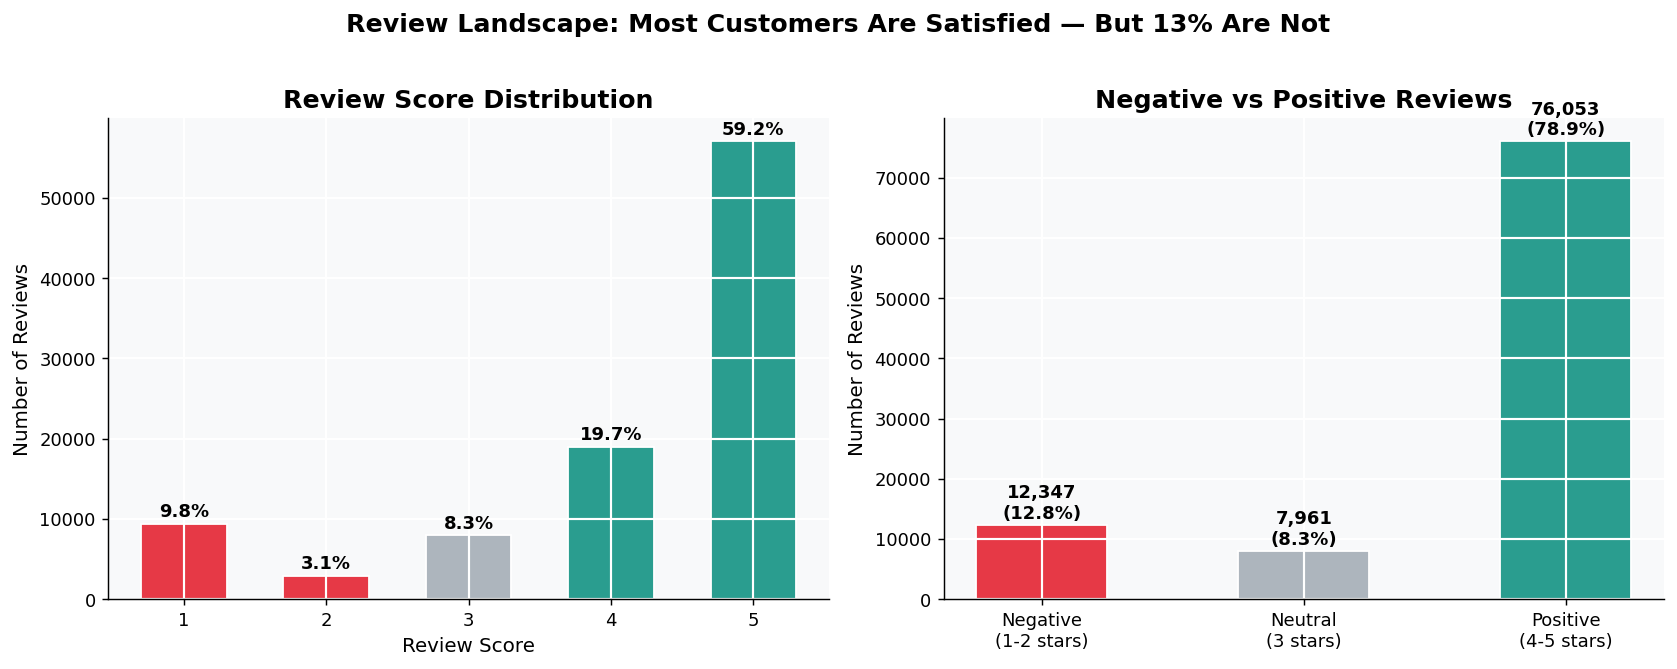

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

score_colors = [NEGATIVE_COLOR, NEGATIVE_COLOR, GRAY, POSITIVE_COLOR, POSITIVE_COLOR]
bars = axes[0].bar(
    score_dist['review_score'], score_dist['total'],
    color=score_colors, edgecolor='white', width=0.6
)
for bar, (_, row) in zip(bars, score_dist.iterrows()):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 400,
        f'{row["pct"]}%', ha='center', va='bottom',
        fontsize=10, fontweight='bold'
    )
axes[0].set_title('Review Score Distribution')
axes[0].set_xlabel('Review Score')
axes[0].set_ylabel('Number of Reviews')
axes[0].set_xticks([1, 2, 3, 4, 5])

neg = score_dist[score_dist['review_score'] <= 2]['total'].sum()
neu = score_dist[score_dist['review_score'] == 3]['total'].sum()
pos = score_dist[score_dist['review_score'] >= 4]['total'].sum()
total = neg + neu + pos

bars2 = axes[1].bar(
    ['Negative\n(1-2 stars)', 'Neutral\n(3 stars)', 'Positive\n(4-5 stars)'],
    [neg, neu, pos],
    color=[NEGATIVE_COLOR, GRAY, POSITIVE_COLOR],
    edgecolor='white', width=0.5
)
for bar, val in zip(bars2, [neg, neu, pos]):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 400,
        f'{val:,}\n({val/total:.1%})',
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )
axes[1].set_title('Negative vs Positive Reviews')
axes[1].set_ylabel('Number of Reviews')

plt.suptitle('Review Landscape: Most Customers Are Satisfied — But 13% Are Not',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 3. Delivery Time & Reviews

**Hypothesis:** Longer delivery times drive negative reviews.

The relationship is clear and monotonic: 1-star orders take an average of 21 days to arrive, while 5-star orders take only 10.6 days.

In [28]:
delivery_reviews = pd.read_sql_query("""
    WITH latest_review AS (
        SELECT order_id, review_score,
               ROW_NUMBER() OVER (PARTITION BY order_id
                                  ORDER BY review_creation_date DESC) AS rn
        FROM reviews WHERE review_score IS NOT NULL
    )
    SELECT
        r.review_score,
        ROUND(
            julianday(o.order_delivered_customer_date) -
            julianday(o.order_purchase_timestamp)
        ) AS delivery_days
    FROM orders o
    JOIN latest_review r ON o.order_id = r.order_id AND r.rn = 1
    WHERE o.order_status = 'delivered'
      AND o.order_delivered_customer_date IS NOT NULL
      AND julianday(o.order_delivered_customer_date) -
          julianday(o.order_purchase_timestamp) BETWEEN 1 AND 90
""", conn)

delivery_reviews['is_negative'] = (delivery_reviews['review_score'] <= 2).astype(int)

print('Avg delivery days by review score:')
print(delivery_reviews.groupby('review_score')['delivery_days']
      .agg(['mean', 'median', 'count']).round(1).to_string())

Avg delivery days by review score:
              mean  median  count
review_score                     
1             20.9    17.0   9320
2             16.4    13.0   2915
3             14.1    12.0   7909
4             12.2    11.0  18877
5             10.6     9.0  56717


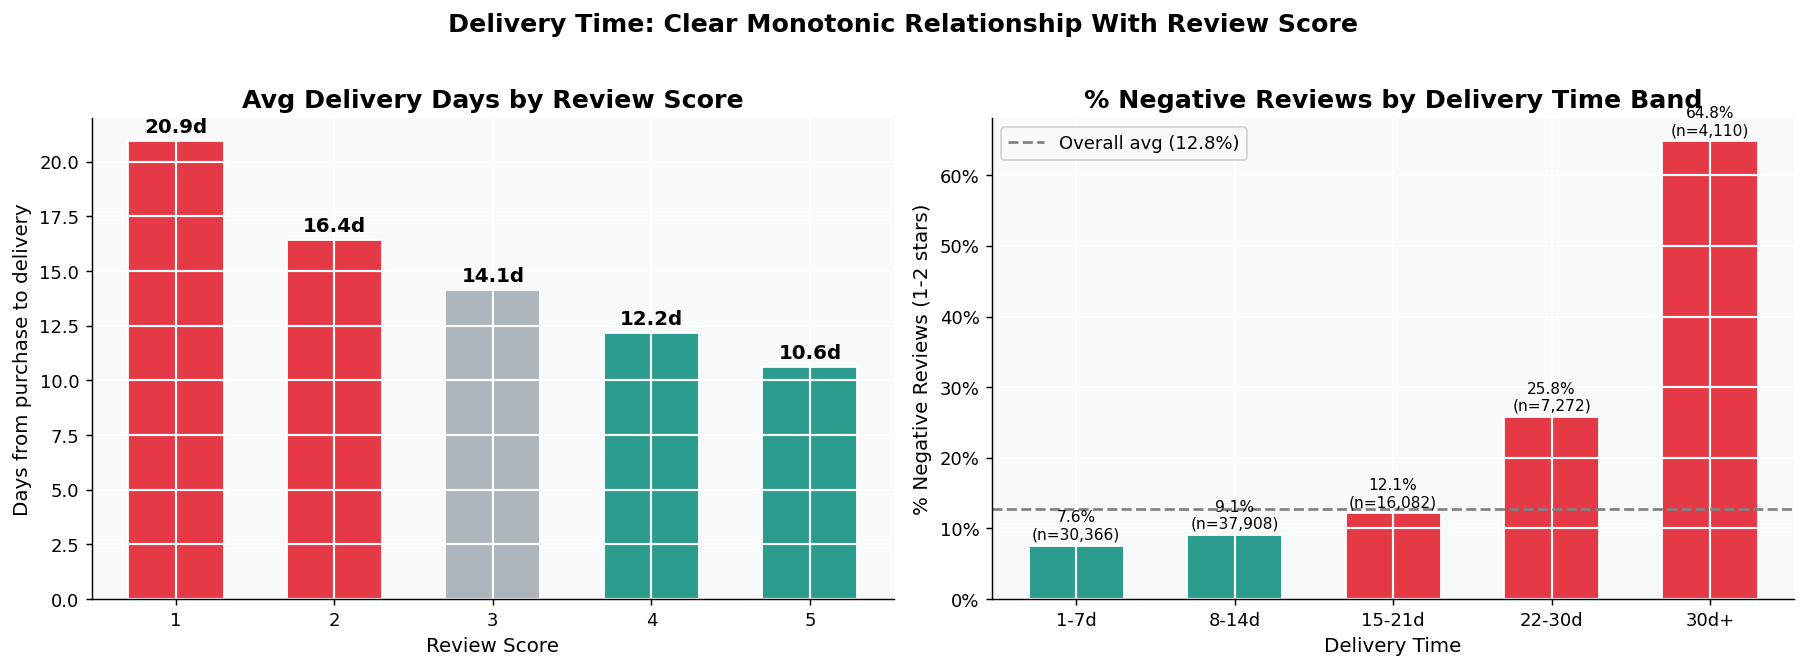

Mann-Whitney U test: p = 0.00e+00
Median delivery: negative reviews = 16d | positive = 10d


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

avg_del = delivery_reviews.groupby('review_score')['delivery_days'].mean()
bar_colors = [NEGATIVE_COLOR, NEGATIVE_COLOR, GRAY, POSITIVE_COLOR, POSITIVE_COLOR]
bars = axes[0].bar(
    avg_del.index, avg_del.values,
    color=bar_colors, edgecolor='white', width=0.6
)
for bar, val in zip(bars, avg_del.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.2,
        f'{val:.1f}d', ha='center', va='bottom',
        fontsize=11, fontweight='bold'
    )
axes[0].set_title('Avg Delivery Days by Review Score')
axes[0].set_xlabel('Review Score')
axes[0].set_ylabel('Days from purchase to delivery')
axes[0].set_xticks([1, 2, 3, 4, 5])

delivery_reviews['delivery_band'] = pd.cut(
    delivery_reviews['delivery_days'],
    bins=[0, 7, 14, 21, 30, 90],
    labels=['1-7d', '8-14d', '15-21d', '22-30d', '30d+']
)
band_stats = delivery_reviews.groupby('delivery_band', observed=True).agg(
    pct_negative=('is_negative', 'mean'),
    count=('is_negative', 'count')
).reset_index()

bar_colors2 = [POSITIVE_COLOR if p < 0.12 else NEGATIVE_COLOR
               for p in band_stats['pct_negative']]
bars2 = axes[1].bar(
    band_stats['delivery_band'].astype(str),
    band_stats['pct_negative'],
    color=bar_colors2, edgecolor='white', width=0.6
)
for bar, (_, row) in zip(bars2, band_stats.iterrows()):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f'{row["pct_negative"]:.1%}\n(n={row["count"]:,})',
        ha='center', va='bottom', fontsize=8.5
    )
axes[1].axhline(
    delivery_reviews['is_negative'].mean(),
    color='gray', linestyle='--', lw=1.5,
    label=f'Overall avg ({delivery_reviews["is_negative"].mean():.1%})'
)
axes[1].set_title('% Negative Reviews by Delivery Time Band')
axes[1].set_xlabel('Delivery Time')
axes[1].set_ylabel('% Negative Reviews (1-2 stars)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'{y:.0%}'))
axes[1].legend()

plt.suptitle('Delivery Time: Clear Monotonic Relationship With Review Score',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

neg_days = delivery_reviews[delivery_reviews['is_negative'] == 1]['delivery_days']
pos_days = delivery_reviews[delivery_reviews['is_negative'] == 0]['delivery_days']
_, p = stats.mannwhitneyu(neg_days, pos_days, alternative='greater')
print(f'Mann-Whitney U test: p = {p:.2e}')
print(f'Median delivery: negative reviews = {neg_days.median():.0f}d | positive = {pos_days.median():.0f}d')

---
## 4. Missing the Promised Date

**Hypothesis:** Failing to meet the estimated delivery date is a stronger predictor than raw delivery time.

The jump is not gradual — it's a cliff. Being just 4-7 days past the promised date pushes the negative rate from 9% to 61%.

In [32]:
late_data = pd.read_sql_query("""
    WITH latest_review AS (
        SELECT order_id, review_score,
               ROW_NUMBER() OVER (PARTITION BY order_id
                                  ORDER BY review_creation_date DESC) AS rn
        FROM reviews WHERE review_score IS NOT NULL
    )
    SELECT
        r.review_score,
        ROUND(
            julianday(o.order_delivered_customer_date) -
            julianday(o.order_estimated_delivery_date)
        ) AS days_late
    FROM orders o
    JOIN latest_review r ON o.order_id = r.order_id AND r.rn = 1
    WHERE o.order_status = 'delivered'
      AND o.order_delivered_customer_date IS NOT NULL
      AND o.order_estimated_delivery_date IS NOT NULL
""", conn)

late_data['is_negative'] = (late_data['review_score'] <= 2).astype(int)
late_data['arrived_late'] = (late_data['days_late'] > 0).astype(int)

ontime_neg = late_data[late_data['arrived_late'] == 0]['is_negative'].mean()
late_neg   = late_data[late_data['arrived_late'] == 1]['is_negative'].mean()
print(f'% negative — on time or early: {ontime_neg:.1%} (n={late_data[late_data["arrived_late"]==0].shape[0]:,})')
print(f'% negative — late:             {late_neg:.1%} (n={late_data[late_data["arrived_late"]==1].shape[0]:,})')

% negative — on time or early: 9.2% (n=88,343)
% negative — late:             55.1% (n=7,481)


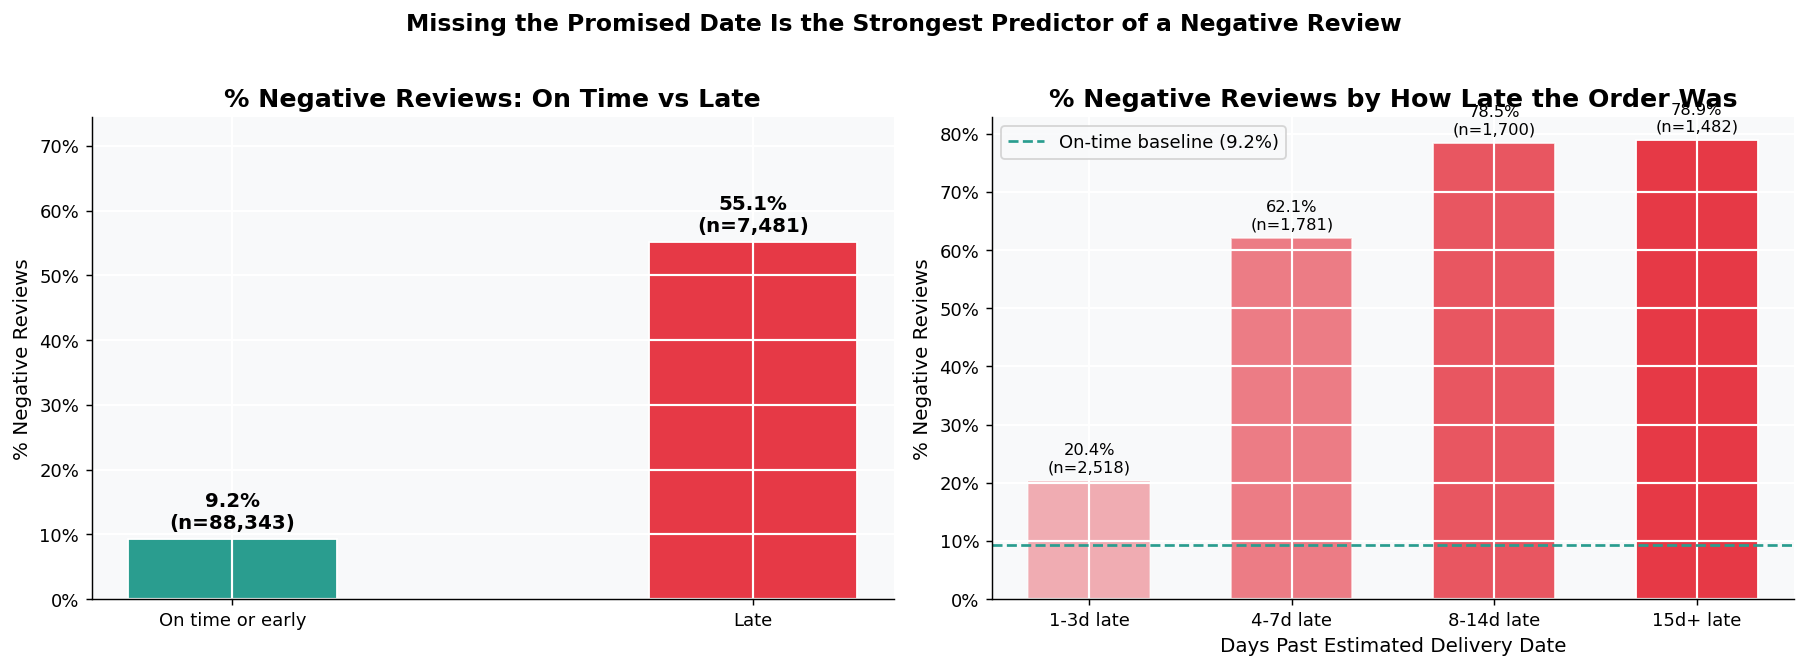

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ontime_n = late_data[late_data['arrived_late'] == 0].shape[0]
late_n   = late_data[late_data['arrived_late'] == 1].shape[0]

bars = axes[0].bar(
    ['On time or early', 'Late'],
    [ontime_neg, late_neg],
    color=[POSITIVE_COLOR, NEGATIVE_COLOR],
    edgecolor='white', width=0.4
)
for bar, val, n in zip(bars, [ontime_neg, late_neg], [ontime_n, late_n]):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f'{val:.1%}\n(n={n:,})',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )
axes[0].set_title('% Negative Reviews: On Time vs Late')
axes[0].set_ylabel('% Negative Reviews')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'{y:.0%}'))
axes[0].set_ylim(0, late_neg * 1.35)

late_only = late_data[late_data['days_late'] > 0].copy()
late_only['days_late_band'] = pd.cut(
    late_only['days_late'],
    bins=[0, 3, 7, 14, 500],
    labels=['1-3d late', '4-7d late', '8-14d late', '15d+ late']
)
late_band = late_only.groupby('days_late_band', observed=True).agg(
    pct_negative=('is_negative', 'mean'),
    count=('is_negative', 'count')
).reset_index()

alphas = [0.4, 0.65, 0.85, 1.0]
for i, (_, row) in enumerate(late_band.iterrows()):
    axes[1].bar(
        i, row['pct_negative'],
        color=NEGATIVE_COLOR, alpha=alphas[i],
        edgecolor='white', width=0.6
    )
    axes[1].text(
        i, row['pct_negative'] + 0.01,
        f'{row["pct_negative"]:.1%}\n(n={row["count"]:,})',
        ha='center', va='bottom', fontsize=9
    )
axes[1].axhline(ontime_neg, color=POSITIVE_COLOR, linestyle='--', lw=1.5,
                label=f'On-time baseline ({ontime_neg:.1%})')
axes[1].set_xticks(range(len(late_band)))
axes[1].set_xticklabels(late_band['days_late_band'].astype(str))
axes[1].set_title('% Negative Reviews by How Late the Order Was')
axes[1].set_xlabel('Days Past Estimated Delivery Date')
axes[1].set_ylabel('% Negative Reviews')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'{y:.0%}'))
axes[1].legend()

plt.suptitle('Missing the Promised Date Is the Strongest Predictor of a Negative Review',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 5. Geographic Breakdown

**Hypothesis:** States further from Sao Paulo have longer deliveries and more negative reviews.

The correlation is moderate (r ≈ 0.63) — delivery time explains a lot of the geographic variation, but not all of it. **Rio de Janeiro is a notable outlier**: 18.3% negative despite only 15.2 average delivery days.

In [36]:
geo_reviews = pd.read_sql_query("""
    WITH latest_review AS (
        SELECT order_id, review_score,
               ROW_NUMBER() OVER (PARTITION BY order_id
                                  ORDER BY review_creation_date DESC) AS rn
        FROM reviews WHERE review_score IS NOT NULL
    )
    SELECT
        c.customer_state                            AS state,
        COUNT(*)                                    AS total_orders,
        ROUND(AVG(r.review_score), 2)               AS avg_score,
        ROUND(100.0 * SUM(CASE WHEN r.review_score <= 2 THEN 1 ELSE 0 END)
              / COUNT(*), 1)                        AS pct_negative,
        ROUND(AVG(
            julianday(o.order_delivered_customer_date) -
            julianday(o.order_purchase_timestamp)
        ), 1)                                       AS avg_delivery_days
    FROM orders o
    JOIN latest_review r ON o.order_id = r.order_id AND r.rn = 1
    JOIN customers c     ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered'
      AND o.order_delivered_customer_date IS NOT NULL
    GROUP BY c.customer_state
    HAVING total_orders >= 100
    ORDER BY pct_negative DESC
""", conn)

print('States with highest % negative reviews:')
print(geo_reviews.head(8).to_string(index=False))
print('\nStates with lowest % negative reviews:')
print(geo_reviews.tail(8).to_string(index=False))

States with highest % negative reviews:
state  total_orders  avg_score  pct_negative  avg_delivery_days
   AL           394       3.85          21.3               24.5
   MA           712       3.83          19.9               21.4
   SE           334       3.91          18.9               21.4
   RJ         12211       3.97          18.3               15.2
   PA           933       3.91          17.9               23.6
   CE          1273       3.94          17.1               21.2
   BA          3229       3.93          17.0               19.2
   PI           471       3.99          16.1               19.5

States with lowest % negative reviews:
state  total_orders  avg_score  pct_negative  avg_delivery_days
   RN           471       4.15          13.0               19.3
   MT           879       4.15          12.7               18.0
   TO           273       4.15          12.1               17.7
   RO           242       4.17          12.0               19.4
   RS          5326     

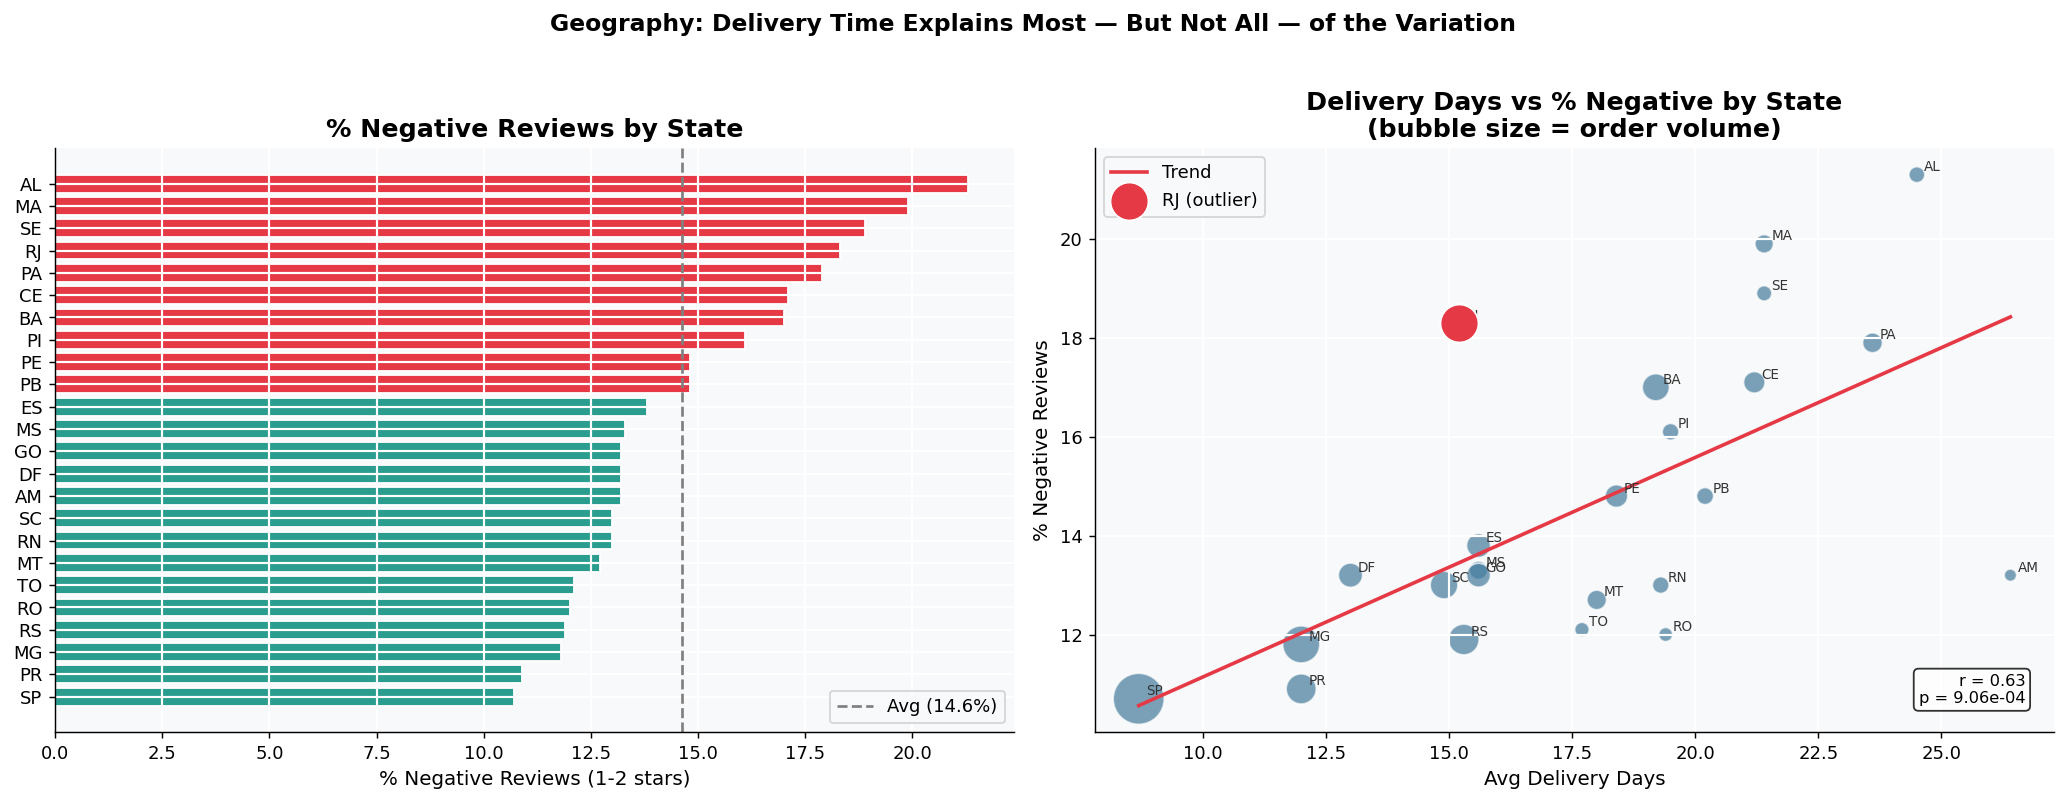

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

geo_sorted  = geo_reviews.sort_values('pct_negative', ascending=True)
avg_neg_geo = geo_reviews['pct_negative'].mean()
bar_colors_geo = [NEGATIVE_COLOR if p > avg_neg_geo else POSITIVE_COLOR
                  for p in geo_sorted['pct_negative']]
axes[0].barh(
    geo_sorted['state'], geo_sorted['pct_negative'],
    color=bar_colors_geo, edgecolor='white'
)
axes[0].axvline(avg_neg_geo, color='gray', linestyle='--', lw=1.5,
                label=f'Avg ({avg_neg_geo:.1f}%)')
axes[0].set_title('% Negative Reviews by State')
axes[0].set_xlabel('% Negative Reviews (1-2 stars)')
axes[0].legend()

axes[1].scatter(
    geo_reviews['avg_delivery_days'],
    geo_reviews['pct_negative'],
    s=np.sqrt(geo_reviews['total_orders']) * 4,
    alpha=0.7, color=NEUTRAL_COLOR, edgecolors='white'
)
z = np.polyfit(geo_reviews['avg_delivery_days'], geo_reviews['pct_negative'], 1)
x_range = np.linspace(geo_reviews['avg_delivery_days'].min(),
                       geo_reviews['avg_delivery_days'].max(), 100)
axes[1].plot(x_range, np.poly1d(z)(x_range),
             color=NEGATIVE_COLOR, lw=2, label='Trend')

# Highlight RJ anomaly
rj = geo_reviews[geo_reviews['state'] == 'RJ'].iloc[0]
axes[1].scatter(rj['avg_delivery_days'], rj['pct_negative'],
                s=np.sqrt(rj['total_orders']) * 4,
                color=NEGATIVE_COLOR, edgecolors='white', zorder=5,
                label='RJ (outlier)')

for _, row in geo_reviews.iterrows():
    axes[1].annotate(
        row['state'],
        (row['avg_delivery_days'], row['pct_negative']),
        textcoords='offset points', xytext=(4, 2),
        fontsize=7.5, color='#333333'
    )

corr, p_val = stats.pearsonr(
    geo_reviews['avg_delivery_days'], geo_reviews['pct_negative'])
axes[1].text(0.97, 0.05, f'r = {corr:.2f}\np = {p_val:.2e}',
             transform=axes[1].transAxes, ha='right', fontsize=9,
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
axes[1].set_title('Delivery Days vs % Negative by State\n(bubble size = order volume)')
axes[1].set_xlabel('Avg Delivery Days')
axes[1].set_ylabel('% Negative Reviews')
axes[1].legend()

plt.suptitle('Geography: Delivery Time Explains Most — But Not All — of the Variation',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 6. Category Breakdown

**Hypothesis:** Some categories generate negative reviews regardless of delivery speed — suggesting a product quality problem.

Categories highlighted in the scatter below have **above-average negative rates despite fast delivery**. These are the ones where the product itself is likely the issue.

In [40]:
category_reviews = pd.read_sql_query("""
    WITH latest_review AS (
        SELECT order_id, review_score,
               ROW_NUMBER() OVER (PARTITION BY order_id
                                  ORDER BY review_creation_date DESC) AS rn
        FROM reviews WHERE review_score IS NOT NULL
    )
    SELECT
        COALESCE(ct.product_category_name_english,
                 p.product_category_name)       AS category,
        COUNT(*)                                AS total_orders,
        ROUND(AVG(r.review_score), 2)           AS avg_score,
        ROUND(100.0 * SUM(CASE WHEN r.review_score <= 2 THEN 1 ELSE 0 END)
              / COUNT(*), 1)                    AS pct_negative,
        ROUND(AVG(
            julianday(o.order_delivered_customer_date) -
            julianday(o.order_purchase_timestamp)
        ), 1)                                   AS avg_delivery_days
    FROM orders o
    JOIN latest_review r  ON o.order_id  = r.order_id AND r.rn = 1
    JOIN order_items oi   ON o.order_id  = oi.order_id
    JOIN products p       ON oi.product_id = p.product_id
    LEFT JOIN category_translation ct
           ON p.product_category_name = ct.product_category_name
    WHERE o.order_status = 'delivered'
      AND o.order_delivered_customer_date IS NOT NULL
      AND p.product_category_name IS NOT NULL
    GROUP BY category
    HAVING total_orders >= 100
    ORDER BY pct_negative DESC
""", conn)

print('Most negative categories:')
print(category_reviews.head(10).to_string(index=False))
print('\nLeast negative categories:')
print(category_reviews.tail(8).to_string(index=False))

Most negative categories:
                 category  total_orders  avg_score  pct_negative  avg_delivery_days
         office_furniture          1654       3.51          25.5               20.8
    fashion_male_clothing           124       3.76          25.0               12.8
          fixed_telephony           252       3.76          23.0               12.6
                    audio           358       3.84          21.5               13.3
             home_confort           427       3.85          19.7               13.5
           bed_bath_table         10831       3.92          18.2               12.8
          furniture_decor          8080       3.95          18.1               12.8
construction_tools_safety           182       3.97          17.6               11.9
        home_construction           592       3.96          17.4               13.2
    furniture_living_room           490       3.93          17.1               13.7

Least negative categories:
                catego

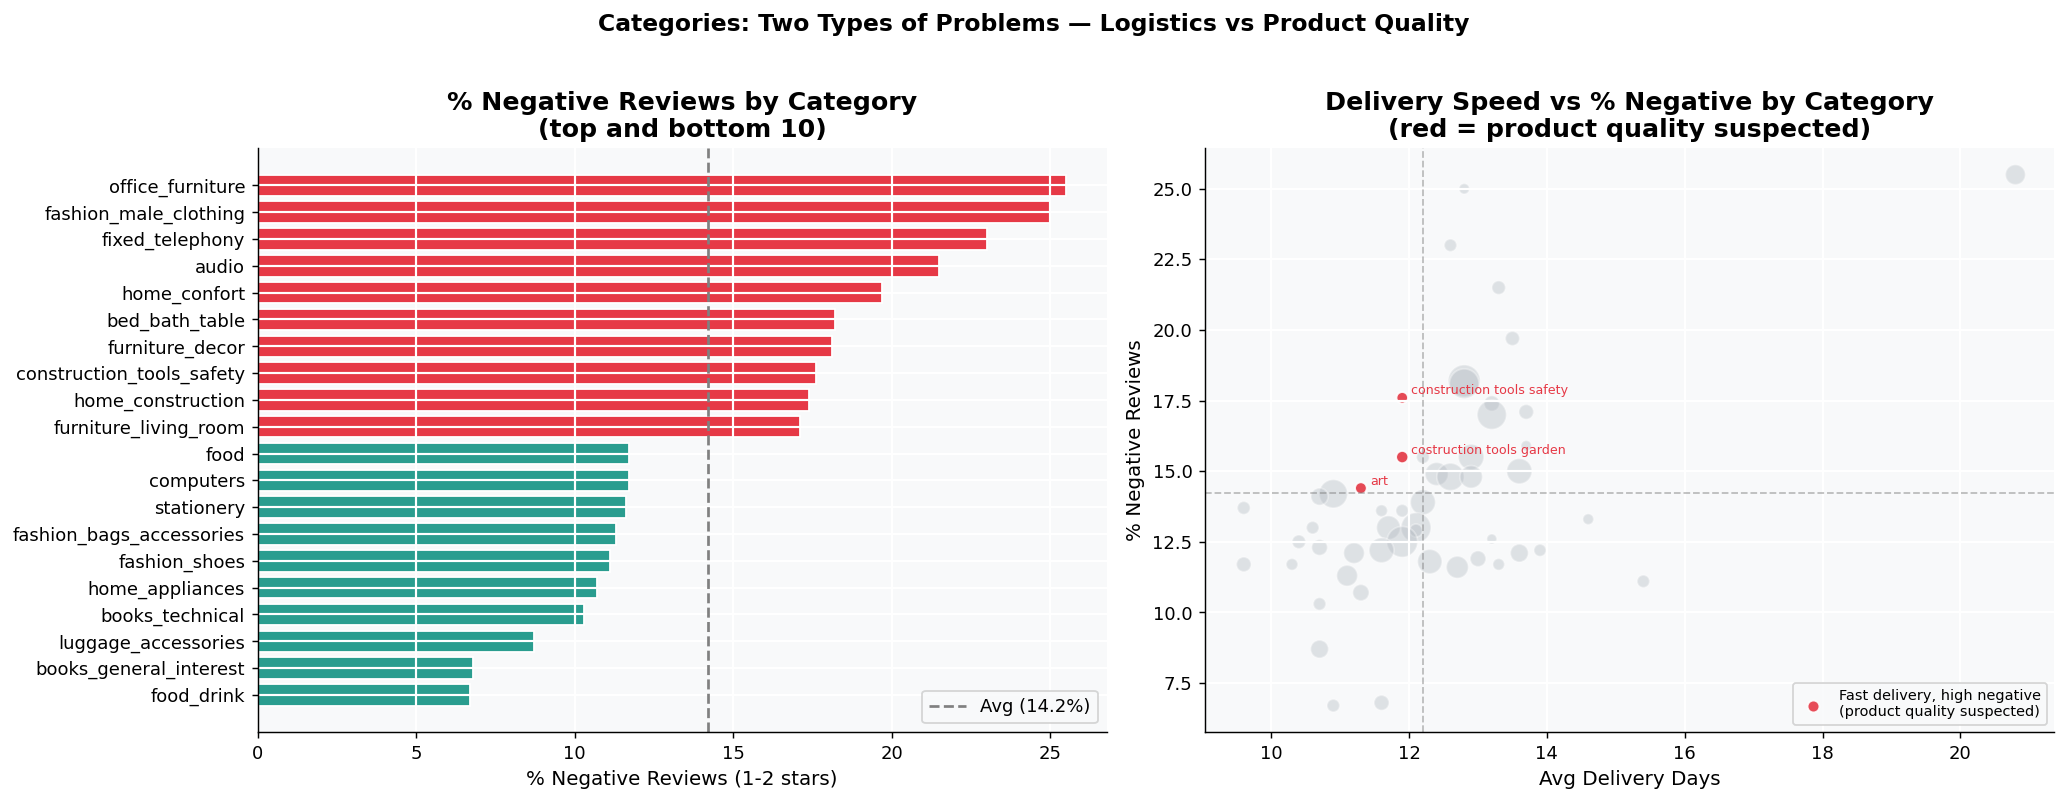


Product quality suspects (fast delivery, above-avg negative rate):
                 category  pct_negative  avg_delivery_days  total_orders
construction_tools_safety          17.6               11.9           182
 costruction_tools_garden          15.5               11.9           232
                      art          14.4               11.3           195


In [42]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

avg_neg_cat    = category_reviews['pct_negative'].mean()
median_delivery = category_reviews['avg_delivery_days'].median()

top10    = category_reviews.head(10)
bot10    = category_reviews.tail(10)
plot_cat = pd.concat([top10, bot10]).drop_duplicates().sort_values('pct_negative')
cat_colors = [NEGATIVE_COLOR if p > avg_neg_cat else POSITIVE_COLOR
              for p in plot_cat['pct_negative']]
axes[0].barh(
    plot_cat['category'], plot_cat['pct_negative'],
    color=cat_colors, edgecolor='white'
)
axes[0].axvline(avg_neg_cat, color='gray', linestyle='--', lw=1.5,
                label=f'Avg ({avg_neg_cat:.1f}%)')
axes[0].set_title('% Negative Reviews by Category\n(top and bottom 10)')
axes[0].set_xlabel('% Negative Reviews (1-2 stars)')
axes[0].legend()

# All categories in gray
axes[1].scatter(
    category_reviews['avg_delivery_days'],
    category_reviews['pct_negative'],
    s=np.sqrt(category_reviews['total_orders']) * 3,
    alpha=0.35, color=GRAY, edgecolors='white'
)

# Product quality suspects
quality_suspects = category_reviews[
    (category_reviews['avg_delivery_days'] < median_delivery) &
    (category_reviews['pct_negative'] > avg_neg_cat)
]
axes[1].scatter(
    quality_suspects['avg_delivery_days'],
    quality_suspects['pct_negative'],
    s=np.sqrt(quality_suspects['total_orders']) * 3,
    color=NEGATIVE_COLOR, edgecolors='white', alpha=0.9,
    label='Fast delivery, high negative\n(product quality suspected)'
)
for _, row in quality_suspects.iterrows():
    axes[1].annotate(
        row['category'].replace('_', ' '),
        (row['avg_delivery_days'], row['pct_negative']),
        textcoords='offset points', xytext=(5, 2),
        fontsize=7, color=NEGATIVE_COLOR
    )

axes[1].axhline(avg_neg_cat, color='gray', linestyle='--', lw=1, alpha=0.5)
axes[1].axvline(median_delivery, color='gray', linestyle='--', lw=1, alpha=0.5)
axes[1].set_title('Delivery Speed vs % Negative by Category\n(red = product quality suspected)')
axes[1].set_xlabel('Avg Delivery Days')
axes[1].set_ylabel('% Negative Reviews')
axes[1].legend(fontsize=8)

plt.suptitle('Categories: Two Types of Problems — Logistics vs Product Quality',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('\nProduct quality suspects (fast delivery, above-avg negative rate):')
print(quality_suspects[['category','pct_negative','avg_delivery_days','total_orders']].to_string(index=False))

---
## 7. Predictive Model

We build a Random Forest classifier to predict whether an order will receive a negative review, using delivery time, lateness, order value, state, and product category as features.

> **Why F1 and not accuracy?** Only 13% of orders are negative. A model that always predicts "positive" would get ~87% accuracy but F1 = 0 — completely useless for identifying negative reviews.

In [44]:
model_data = pd.read_sql_query("""
    WITH latest_review AS (
        SELECT order_id, review_score,
               ROW_NUMBER() OVER (PARTITION BY order_id
                                  ORDER BY review_creation_date DESC) AS rn
        FROM reviews WHERE review_score IS NOT NULL
    )
    SELECT
        r.review_score,
        ROUND(
            julianday(o.order_delivered_customer_date) -
            julianday(o.order_purchase_timestamp)
        ) AS delivery_days,
        ROUND(
            julianday(o.order_delivered_customer_date) -
            julianday(o.order_estimated_delivery_date)
        ) AS days_late,
        p.payment_value,
        c.customer_state,
        COALESCE(ct.product_category_name_english,
                 pr.product_category_name)      AS category
    FROM orders o
    JOIN latest_review r  ON o.order_id   = r.order_id AND r.rn = 1
    JOIN payments p       ON o.order_id   = p.order_id
    JOIN customers c      ON o.customer_id = c.customer_id
    JOIN order_items oi   ON o.order_id   = oi.order_id
    JOIN products pr      ON oi.product_id = pr.product_id
    LEFT JOIN category_translation ct
           ON pr.product_category_name = ct.product_category_name
    WHERE o.order_status = 'delivered'
      AND o.order_delivered_customer_date IS NOT NULL
      AND o.order_estimated_delivery_date IS NOT NULL
      AND pr.product_category_name IS NOT NULL
""", conn)

model_data['is_negative'] = (model_data['review_score'] <= 2).astype(int)
model_data = model_data.dropna(subset=['delivery_days', 'days_late', 'payment_value'])

le_state    = LabelEncoder()
le_category = LabelEncoder()
model_data['state_enc']    = le_state.fit_transform(model_data['customer_state'])
model_data['category_enc'] = le_category.fit_transform(model_data['category'])

features = ['delivery_days', 'days_late', 'payment_value', 'state_enc', 'category_enc']
X = model_data[features]
y = model_data['is_negative']

print(f'Dataset: {len(X):,} orders | Negative rate: {y.mean():.1%}')

Dataset: 112,550 orders | Negative rate: 14.7%


Random Forest — 5-fold Stratified CV
  F1:       0.387 +/- 0.011
  Accuracy: 0.772 +/- 0.006
  Baseline accuracy (always predict positive): 85.3%


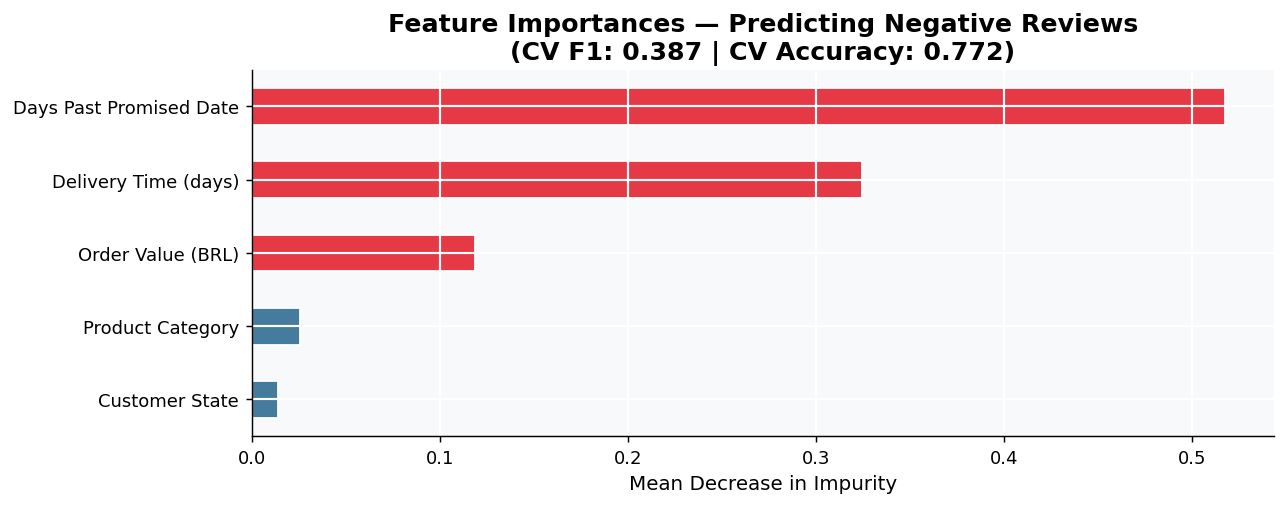

In [46]:
rf = RandomForestClassifier(
    n_estimators=200, max_depth=6, min_samples_leaf=10,
    class_weight='balanced', random_state=42
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_f1  = cross_val_score(rf, X, y, cv=cv, scoring='f1')
cv_acc = cross_val_score(rf, X, y, cv=cv, scoring='accuracy')

print('Random Forest — 5-fold Stratified CV')
print(f'  F1:       {cv_f1.mean():.3f} +/- {cv_f1.std():.3f}')
print(f'  Accuracy: {cv_acc.mean():.3f} +/- {cv_acc.std():.3f}')
print(f'  Baseline accuracy (always predict positive): {1-y.mean():.1%}')

rf.fit(X, y)

label_map = {
    'delivery_days':  'Delivery Time (days)',
    'days_late':      'Days Past Promised Date',
    'payment_value':  'Order Value (BRL)',
    'state_enc':      'Customer State',
    'category_enc':   'Product Category'
}
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)
importances.index = [label_map[f] for f in importances.index]

fig, ax = plt.subplots(figsize=(10, 4))
colors = [NEGATIVE_COLOR if v >= importances.median() else NEUTRAL_COLOR
          for v in importances.values]
importances.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_title(
    f'Feature Importances — Predicting Negative Reviews\n'
    f'(CV F1: {cv_f1.mean():.3f} | CV Accuracy: {cv_acc.mean():.3f})'
)
ax.set_xlabel('Mean Decrease in Impurity')
plt.tight_layout()
plt.show()

---
## 8. Conclusions & Recommendations

### What the data tells us

**1. The problem is real and concentrated in logistics**  
13% of delivered orders receive a negative review. The distribution skews to 1-star — when something goes wrong, it tends to go badly wrong.

**2. Missing the promised date is the primary driver**  
On-time orders: 9.2% negative. Orders 4-7 days late: 61% negative. Orders 8+ days late: ~79% negative. This is the clearest and most actionable finding.

**3. Expectation management matters as much as actual speed**  
The jump from on-time to 1-3 days late (9.2% to 19.1%) happens before delivery is unusually slow in absolute terms. Setting more accurate estimated delivery dates would reduce negative reviews even without changing logistics.

**4. Rio de Janeiro is an outlier worth investigating**  
RJ has 18.3% negative reviews despite only 15.2 average delivery days — higher than states with much slower delivery. This suggests a problem specific to the RJ region beyond raw delivery time.

**5. Some categories have product quality issues**  
Fixed telephony, audio, and furniture categories show above-average negative rates despite fast delivery. These require product-level investigation, not logistics improvement.

### Recommendations

| Priority | Action | Rationale |
|---|---|---|
| High | Improve delivery date estimation accuracy | Biggest single driver of negative reviews |
| High | Investigate RJ logistics specifically | High negative rate not explained by delivery time |
| Medium | Audit product quality in flagged categories | Fixed telephony, audio, furniture have product-level issues |
| Medium | Improve logistics for northern/northeastern states | Structural delivery time problem |

### Limitations

- Review text was not analyzed — we cannot separate delivery complaints from product complaints within a single review.
- The model predicts correlation, not causation.
- Customers who do not leave reviews are excluded — their satisfaction level is unknown.
- Data covers 2016-2018; logistics infrastructure may have changed.

---
*Analysis combining SQL-based data extraction with Python modeling on a real e-commerce dataset.*